In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from factor_diffusion_train import FACTOR_NAMES

In [30]:
df = pd.read_csv("data/factor_returns_regression.csv")[FACTOR_NAMES]
df.shape

(3913, 6)

In [31]:
sampled = np.load("samples/factor_ddpm_2048.npy")
sampled.shape

(2048, 6)

In [32]:
print(np.corrcoef(df.values.T))

[[ 1.          0.04880716  0.08484014 -0.22977029 -0.17966169 -0.11235317]
 [ 0.04880716  1.          0.03031687  0.15817752 -0.04792283  0.16687005]
 [ 0.08484014  0.03031687  1.          0.0552859   0.11056405 -0.17173548]
 [-0.22977029  0.15817752  0.0552859   1.          0.1670121   0.3764994 ]
 [-0.17966169 -0.04792283  0.11056405  0.1670121   1.         -0.19645607]
 [-0.11235317  0.16687005 -0.17173548  0.3764994  -0.19645607  1.        ]]


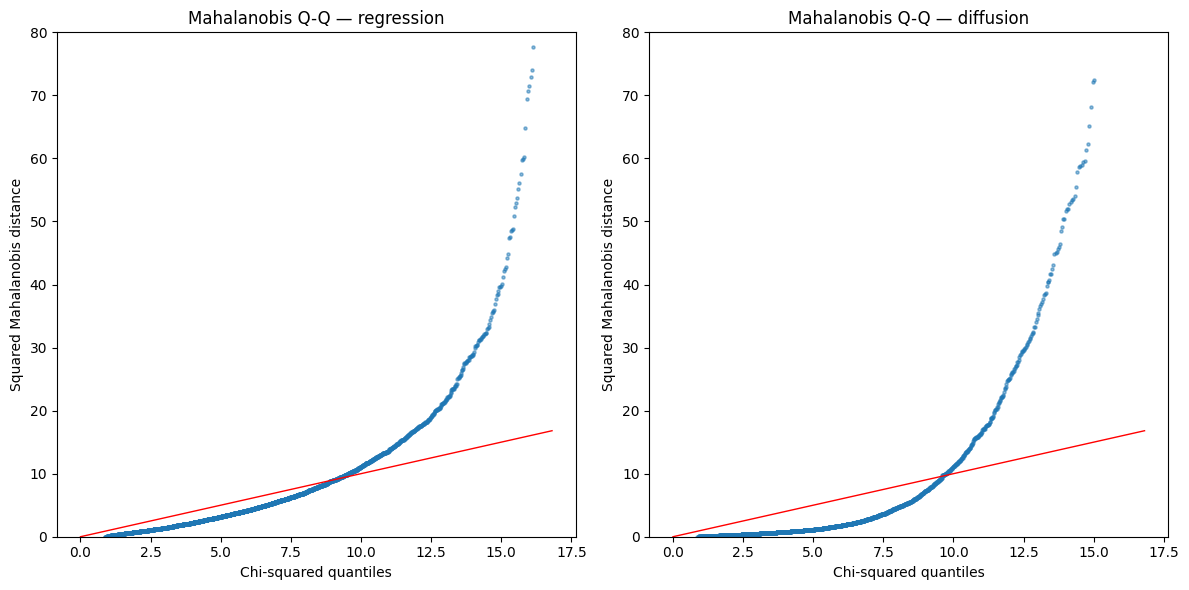

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

axs = [(ax1, df.values, "regression"),
                     (ax2, sampled, "diffusion")]
for ax, X, title in axs:
    p = X.shape[1]
    mean = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    diff = X - mean
    d2 = (diff @ np.linalg.inv(cov) * diff).sum(axis=1)
    quantiles = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.set_ylim(0, 80)
    ax.scatter(quantiles, np.sort(d2), s=5, alpha=0.5)
    ax.plot([0, quantiles.max()], [0, quantiles.max()], color="red", linewidth=1)
    ax.set_xlabel("Chi-squared quantiles")
    ax.set_ylabel("Squared Mahalanobis distance")
    ax.set_title(f"Mahalanobis Q-Q — {title}")

plt.tight_layout()
plt.show()